In [2]:
import numpy as np
import matplotlib as mpl
import glob
import os
import matplotlib.pyplot as plt
import numpy.ma as ma
from scipy import stats
import xarray as xr
plt.rcParams.update({'font.size': 12})

In [3]:
mydir = '../processed_netcdf/'
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
nm = 12
alph = ['(a)','(b)','(c)','(d)']
myhemi = ['SH','NH']
smallhemi=['sh','nh']
gencolours = ['blue','red','green','black']
ls = ['-','-.',':','--']
ls = np.tile(ls,20)
colors = {'historical':'grey','ssp245':'#EF550F','ssp126':'#003466', 'ssp585':'#990002',
         'rcp85':'#990002','rcp45':'#5492CD'}


In [4]:
obs_ds =  xr.open_dataset(mydir+'processed_OBS_sia_1979-2018.nc').sel(year=slice('1979','2018'))

loses  ssp126 Sep 14.837459332059723
loses  ssp245 Sep 26.386660365948885
loses  ssp585 Sep 50.00728230280027
loses  ssp126 Feb 28.81078534030361
loses  ssp245 Feb 66.01771818451428
loses  ssp585 Feb 90.89235140595476


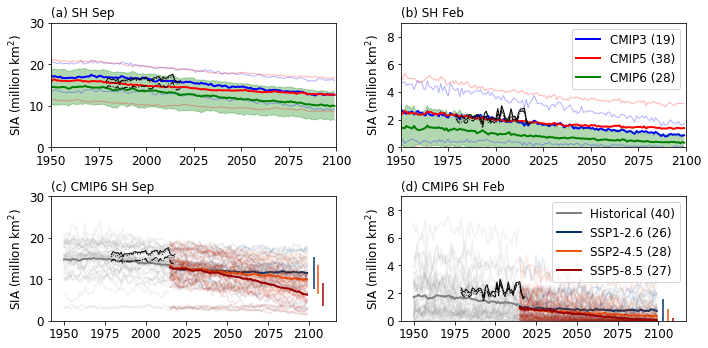

In [8]:
plt.rcParams.update({'font.size': 12})
exps = ['historical+SRES1AB','rcp45','ssp245']
suffix = ['','','_updated']
scenlabels = ['Historical','SSP1-2.6','SSP2-4.5','SSP5-8.5']
scenarios = ['historical','ssp126','ssp245','ssp585']
years = {'historical':np.arange(1950,2015),'ssp126':np.arange(2015,2100),
             'ssp245':np.arange(2015,2100),'ssp585':np.arange(2015,2100)}
fig = plt.figure(figsize=(10,5))

for m, mon in enumerate([8,1]):
    
    ax = plt.subplot(2,2,m+1)
    ax.set_ylim([0,[30.,9.][m]])
    ax.set_ylabel('SIA (million km$^2$)')
    ax.set_title(alph[m]+' SH '+months[mon],loc='left',fontsize=12)
    
    for g,gen in enumerate(['CMIP3','CMIP5','CMIP6']):
        model_ds = xr.open_dataset(mydir+'processed_'+gen+'_sia_'+exps[g]+'_r1'+suffix[g]+'.nc').sel(year=slice('1950','2099')).isel(month=mon)
   
        mmm = model_ds.sia_sh.mean(dim='name')
        if g==2:
            histmm = mmm.sel(year=slice('1979','2014')).mean(dim='year').values
        mmsd = model_ds.sia_sh.std(dim='name')

        ax.plot(model_ds.year,mmm + mmsd, c=gencolours[g],linewidth=1,alpha=.3)        
        ax.plot(model_ds.year,mmm - mmsd, c=gencolours[g],linewidth=1,alpha=.3)        
        ax.plot(model_ds.year,mmm, c=gencolours[g],linewidth=2,label=gen+' ('+str(len(model_ds.name))+')')     
                
        ax.set_xlim([1950,2100]) 
        
    ax.fill_between(model_ds.year,mmm +mmsd,mmm-mmsd, facecolor=gencolours[g],alpha=.3)
    
    for o in range(len(obs_ds.name)):
        ax.plot(obs_ds.year,obs_ds.sia_sh.isel(month=mon).isel(name=o),color='k',linewidth=1,linestyle=ls[o])

    obsmean = obs_ds.sia_sh.isel(month=mon).mean(dim='year').mean(dim='name').values
    
    if m==1:  
        plt.legend(loc='upper right') 
        
    #next set of subplots
    ax = plt.subplot(2,2,m+1+2)
    ax.set_ylim([0,[30.,9.][m]])
    ax.set_ylabel('SIA (million km$^2$)')
    ax.set_title(alph[m+2]+' CMIP6 SH '+months[mon],loc='left',fontsize=12)
  
    for j,scenario in enumerate(scenarios):
        starty = years[scenario][0]
        endy = years[scenario][-1]
        model_ds = xr.open_dataset(mydir+'processed_'+gen+'_sia_'+scenario+'_r1'+suffix[g]+'.nc').sel(year=slice(starty,endy)).isel(month=mon)
        
        mmm = model_ds.sia_sh.mean(dim='name')
        mmsd = model_ds.sia_sh.std(dim='name')
        
        for model in range(len(model_ds.name)):
            ax.plot(years[scenario],model_ds.sia_sh.isel(name=model),color=colors[scenario],alpha=0.1)
        
        plt.plot(years[scenario],mmm,color=colors[scenario],linewidth=2,label=scenlabels[j]+' ('+str(len(model_ds.name))+')')
        
        if scenario != 'historical':
            plt.vlines(2100+3*j,ymin=(mmm-mmsd)[-1],ymax=(mmm+mmsd)[-1],color=colors[scenario],linewidth=1.5)
            endofc = mmm.sel(year=slice('2090','2099')).mean(dim='year').values
            print('loses ',scenario,months[mon],100.-(100.*endofc/histmm))
       
    for o in range(len(obs_ds.name)):
        ax.plot(obs_ds.year,obs_ds.sia_sh.isel(month=mon).isel(name=o),color='k',linewidth=1,linestyle=ls[o])
   
    if m==1:    
        plt.legend()    
     
plt.tight_layout()
plt.show()
fig.savefig('fig4',bbox_inches='tight',dpi=600)
plt.close()